# EURNOK V. EURSEK

### IMPORT

In [1]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from screener import SCREENER
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET
from descriptive import DESCRIPTIVE

### PARAMS

In [ ]:
TRAIN_DAYS = 30
COINT_WINDOW = 300          # Keep: Captures the short-term microstructure beta
Z_WINDOW = 100              # Keep: Fast rolling mean to fade bid/ask bounces

ENTRY_Z = 1.50              # TWEAKED: Raised from 1.25
EXIT_Z = -0.25              # Keep: Captures momentum past the mean
AR_LIMIT = 0.985            # TWEAKED: Tightened from 0.995
DANGER_THRESHOLD = 0.95     # TWEAKED: Raised from 0.90

K_REGIMES = 2
WINSORIZE_STD = 3.0          # TWEAKED: Let the 3rd regime handle the tails

### DESCRIPTIVE

built 16027 rows

=== LIQUIDITY PROFILE (Median Spreads) ===
Tightest 4h Window: 9:00 to 12:00 UTC
Overall Median Spread: A=1.78 | B=1.33 bps


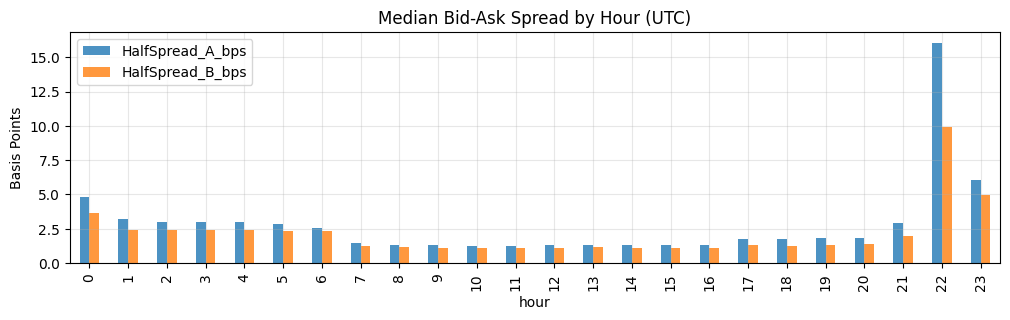


=== RETURN STATISTICS (Log Scale) ===
         Mean (bps)  Vol (bps)      Skew   Kurtosis
EUR/NOK    0.013468   2.787789 -0.047015   5.157068
EUR/SEK    0.004545   2.296403 -0.184318  11.139117

[!] WARNING: High Kurtosis detected (>10). Gaussian Markov Models (HMM) 
    will likely struggle with false-positive 'Danger' regimes.


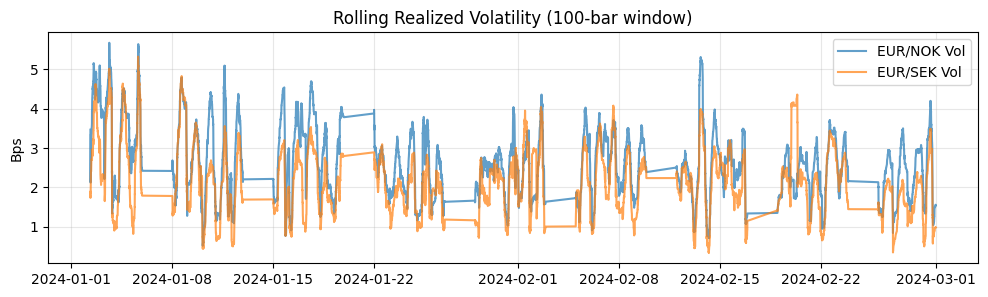

In [3]:
eda_months = ["202401", "202402"]
eda_files = [
    [f"../data/processed/eurnok_dukascopy_ask_{m}.parquet" for m in eda_months],
    [f"../data/processed/eurnok_dukascopy_bid_{m}.parquet" for m in eda_months],
    [f"../data/processed/eursek_dukascopy_ask_{m}.parquet" for m in eda_months],
    [f"../data/processed/eursek_dukascopy_bid_{m}.parquet" for m in eda_months],
]

# 2. Build 24-hours for the EDA
builder_eda = SPREAD(agg_type='volume', threshold=1000, active_hours=(0, 24)) 
df_raw_eda = builder_eda.build(eda_files)

# 3. Run Descriptive Stats to see the Bar Chart
eda = DESCRIPTIVE(df_raw_eda, "EUR/NOK", "EUR/SEK")
eda.generate_full_eda()

### DATA

In [4]:
months = [
    "202401", "202402", "202403", "202404", "202405", "202406",
    "202407", "202408", "202409", "202410", "202411", "202412",
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512"
]

my_files = [
    [f"../data/processed/eurnok_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eurnok_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/eursek_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eursek_dukascopy_bid_{m}.parquet" for m in months],
]

### SPREAD

built 63053 rows


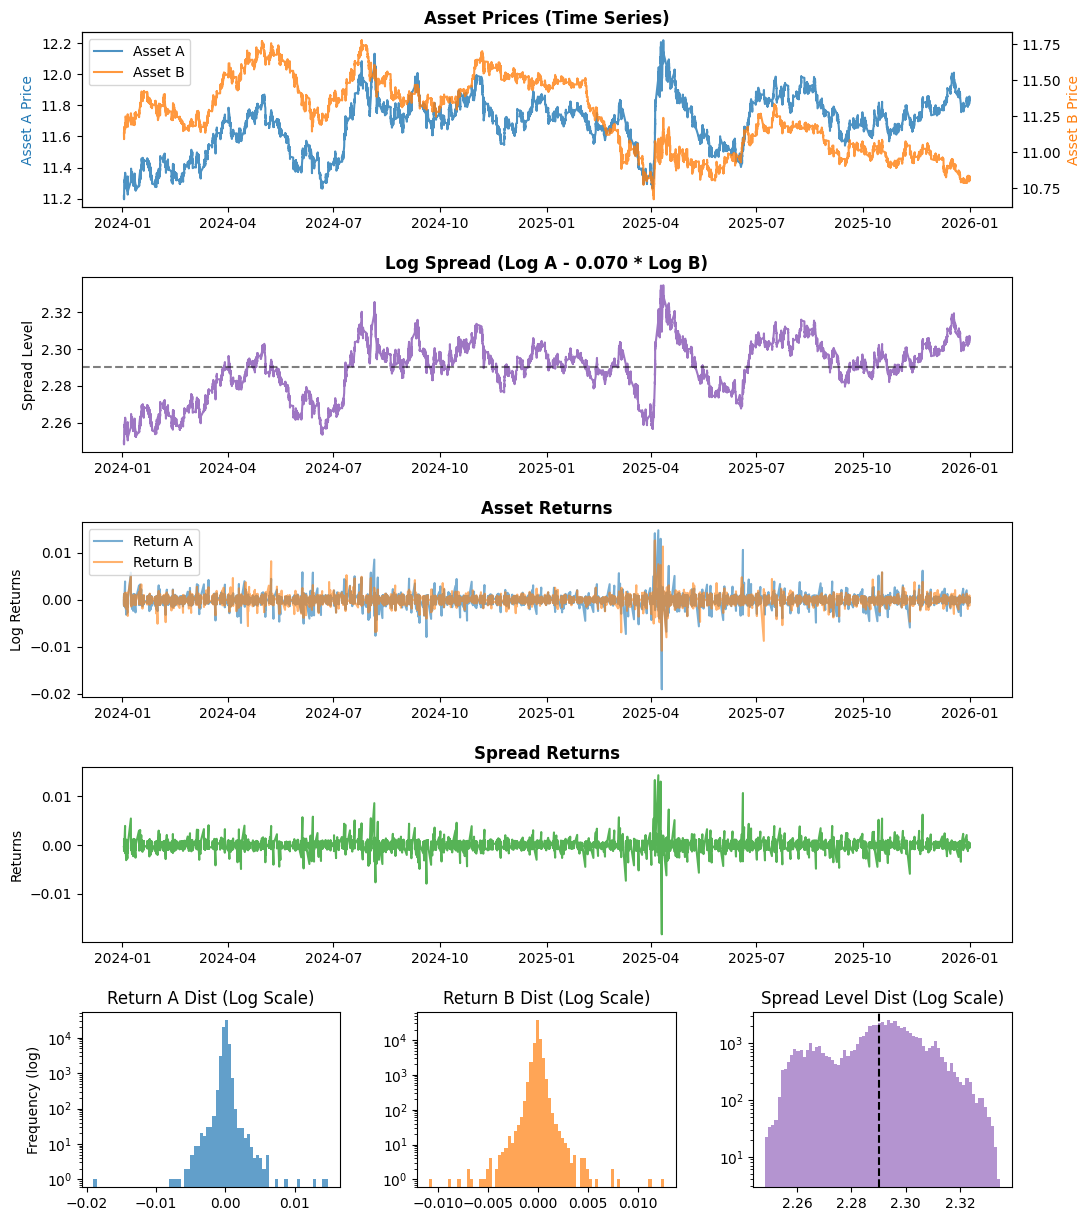

In [5]:
builder = SPREAD(agg_type='volume', threshold=1000, active_hours=(8, 16)) # Build all hours first
df = builder.build(my_files)
builder.plot_diagnostics()

### DESCRIPTIVE


=== LIQUIDITY PROFILE (Median Spreads) ===
Tightest 4h Window: 9:00 to 12:00 UTC
Overall Median Spread: A=1.16 | B=1.04 bps


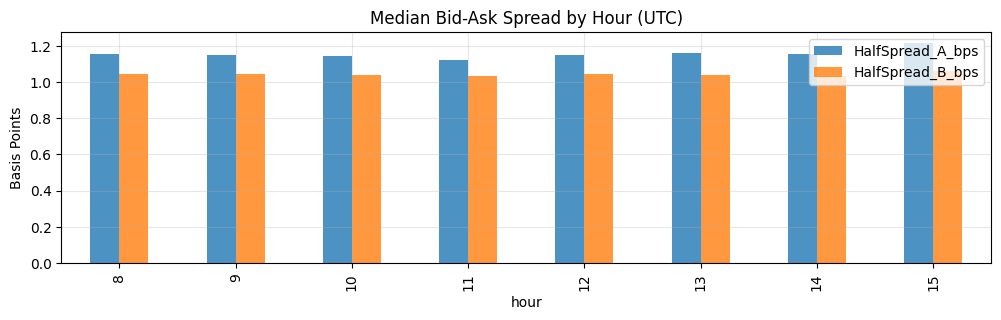


=== RETURN STATISTICS (Log Scale) ===
        Mean (bps)  Vol (bps)      Skew    Kurtosis
EURNOK    0.008603   4.229485  0.413951  158.619065
EURSEK   -0.004462   3.644859  0.420562   95.093211

[!] WARNING: High Kurtosis detected (>10). Gaussian Markov Models (HMM) 
    will likely struggle with false-positive 'Danger' regimes.


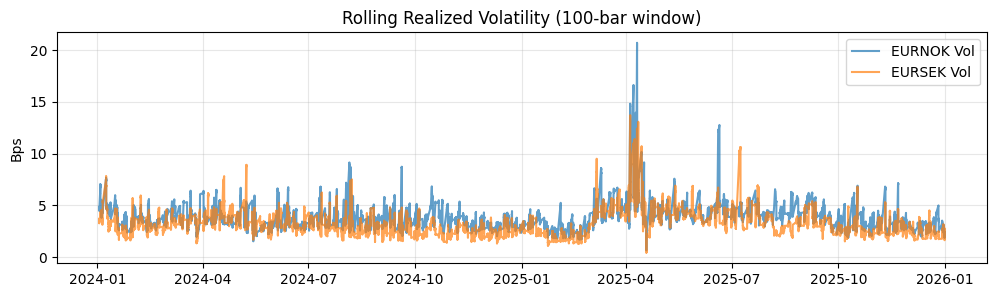

In [6]:
eda = DESCRIPTIVE(df, name_a="EURNOK", name_b="EURSEK")
eda.generate_full_eda()

### SCREENER


=== COINTEGRATION SCREENER ===
Full: p=0.0226 | half-life=1806.8 | β=0.0695

Rolling (2000-bar, step 200, n=306):
  p<0.05: 6.9% | p<0.10: 11.4%
  half-life: 114.1 (IQR 69–206)
  β: 0.7176 ±0.6580 [-1.3496, 2.3727]


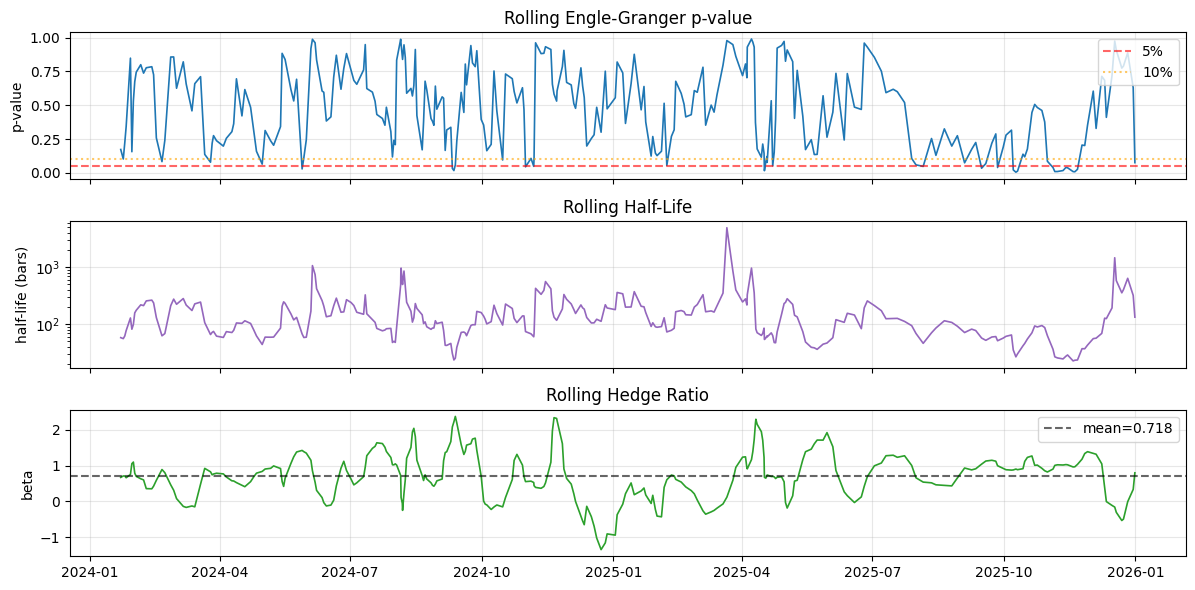

In [7]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report(rolling_window=2000, rolling_step=200)

### MORE IMPORTS

In [8]:
import importlib
import engine, backtester, tearsheet
importlib.reload(engine)
importlib.reload(backtester)
importlib.reload(tearsheet)

from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

In [ ]:
live_trading_data, df_params = ENGINE.walk_forward(
    df=df, 
    train_days=TRAIN_DAYS, 
    coint_window=COINT_WINDOW, 
    z_window=Z_WINDOW,
    k_regimes=K_REGIMES,
    winsorize_std=WINSORIZE_STD
)

Running Engine | train_days=30 | coint_window=300 | z_window=100
[2024-02-13] Beta: 1.7094 | AR: 0.9821
[2024-02-27] Beta: -0.8942 | AR: 0.9861
[2024-03-12] Beta: 1.3906 | AR: 0.9836
[2024-03-26] Beta: 0.7208 | AR: 0.9844
[2024-04-09] Beta: 0.4000 | AR: 0.9828
[2024-04-23] Beta: 0.2627 | AR: 0.9788
[2024-05-07] Beta: 2.5633 | AR: 0.9814
[2024-05-21] Beta: 0.3227 | AR: 0.9845
[2024-06-04] Beta: 0.0707 | AR: 0.9847
[2024-06-18] Beta: 0.9915 | AR: 0.9882
[2024-07-02] Beta: 0.6506 | AR: 0.9882
[2024-07-16] Beta: 0.7421 | AR: 0.9894
[2024-07-30] Beta: 1.2632 | AR: 0.9878
[2024-08-13] Beta: -0.9229 | AR: 0.9899
[2024-08-27] Beta: 1.2942 | AR: 0.9866
[2024-09-10] Beta: 1.8296 | AR: 0.9870
[2024-09-24] Beta: 1.7518 | AR: 0.9769
[2024-10-08] Beta: 0.2019 | AR: 0.9857
[2024-10-22] Beta: 0.5953 | AR: 0.9877
[2024-11-05] Beta: 0.0895 | AR: 0.9855
[2024-11-19] Beta: 1.2360 | AR: 0.9811
[2024-12-03] Beta: -0.6533 | AR: 0.9860
[2024-12-17] Beta: -0.4992 | AR: 0.9879
[2025-01-02] Beta: 1.0417 | AR: 0.

In [10]:
bt = BACKTESTER(live_trading_data)
results_df = bt.run(
    base_z=ENTRY_Z,
    exit_z=EXIT_Z,
    danger_threshold=DANGER_THRESHOLD,   
    ar_limit=AR_LIMIT,
    fee_bps=0.5,
    slippage_mode='half_spread'
)


                      QUANTITATIVE STRATEGY TEARSHEET                      
Metric                         | Baseline     | AR           | MS_AR        |
-----------------------------------------------------------------------------

--- FINANCIAL METRICS ---
Total Return (bps)             | -2445.48     | -936.89      | -1053.72     |
Annual Return (bps)            | -1260.25     | -482.81      | -543.02      |
Annual Volatility (bps)        | 728.59       | 533.75       | 526.49       |
Max Drawdown (bps)             | -2756.77     | -1233.92     | -1278.64     |
Sharpe Ratio                   | -1.73        | -0.90        | -1.03        |
Sortino Ratio                  | -1.89        | -0.69        | -0.79        |
Calmar Ratio                   | 0.46         | 0.39         | 0.42         |
Gross Profit (bps)             | 65254.88     | 33312.52     | 32732.94     |
Gross Loss (bps)               | 67700.35     | 34249.41     | 33786.66     |
Profit Factor                  | 0.96 

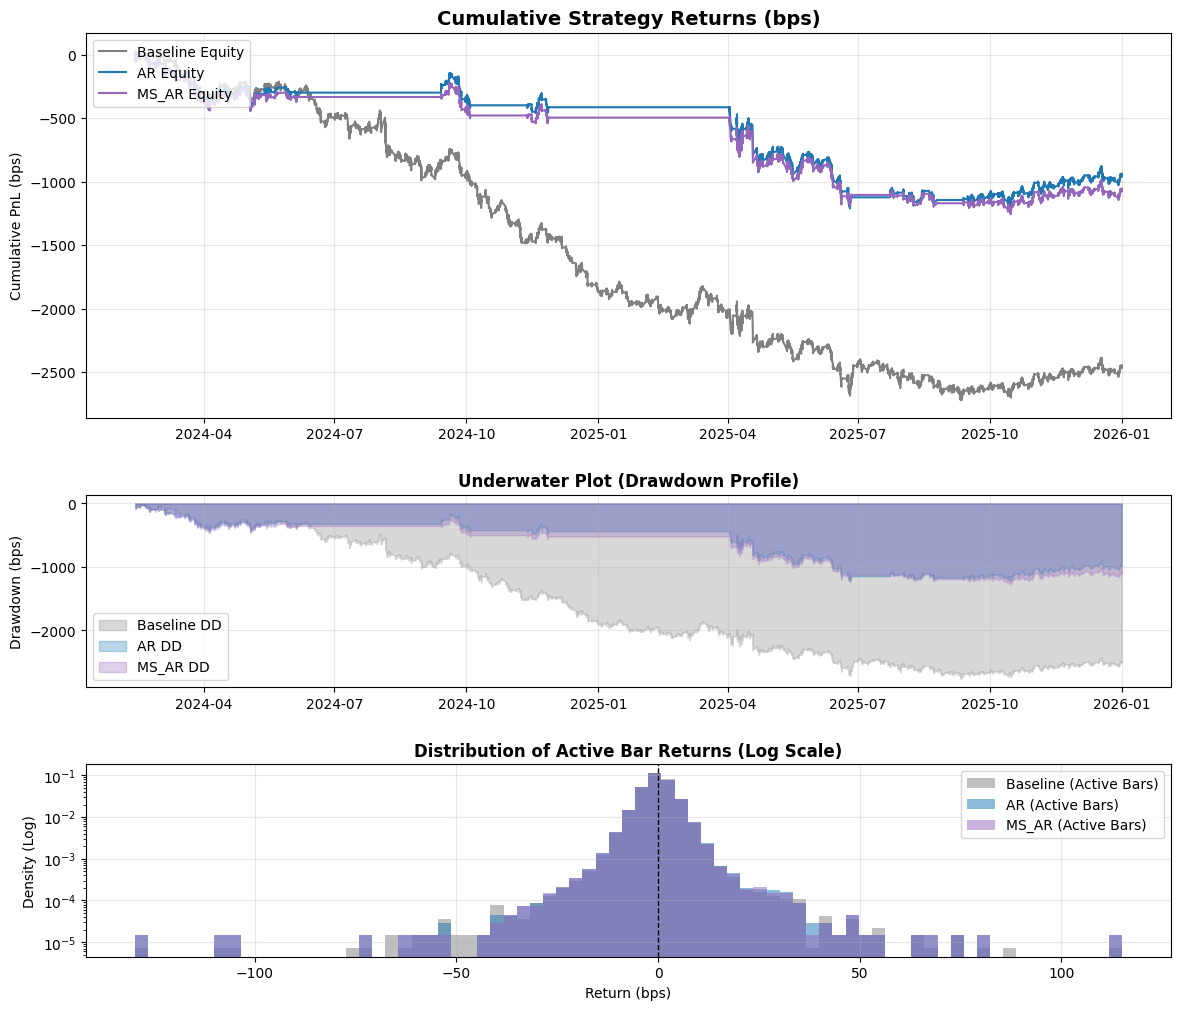

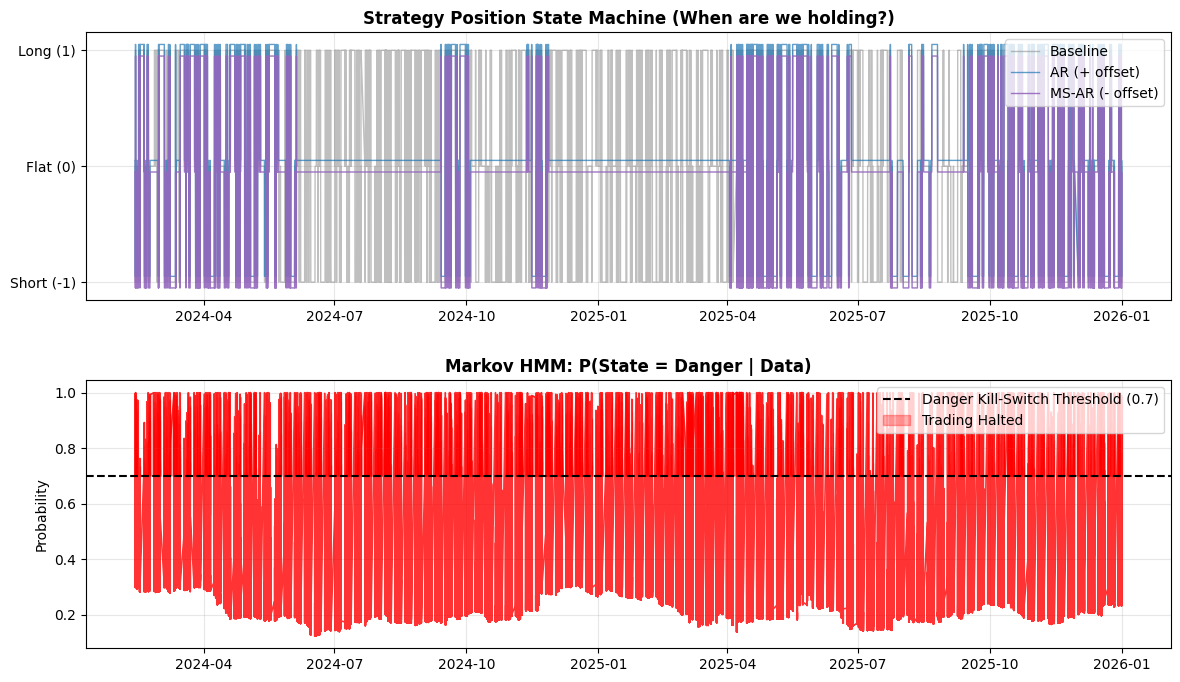

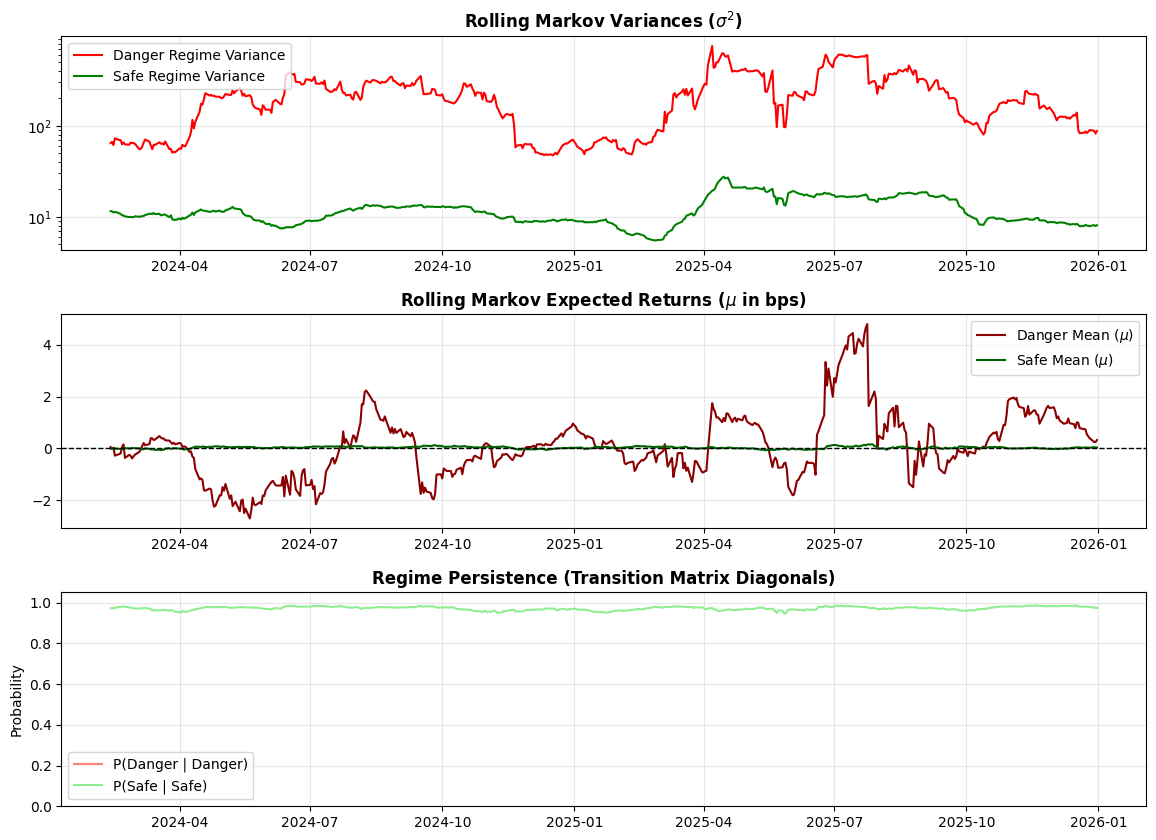

In [11]:
ts = TEARSHEET(results_df, df_params=df_params)
ts.generate_report()
ts.plot_performance()
ts.plot_positions_and_regimes()
ts.plot_markov_dynamics()